In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math

In [2]:
df =pd.read_csv('clean_dataset.csv')
display(df.head())

,country,year,region,economic_tier,happiness_rank,global_hunger_rank,human_development_rank,gdp_per_capita_rank,life_expectancy_rank,corruption_perception_rank,democracy_rank,gini_rank,press_freedom_rank,global_peace_rank,environmental_performance_rank
0,Afghanistan,2000,Asia,low,195,208,187,212,186,185,215,183,214,216,212
1,Afghanistan,2001,Asia,low,198,207,188,215,186,185,215,180,214,217,214
2,Afghanistan,2002,Asia,low,196,208,192,213,185,185,215,174,214,217,213
3,Afghanistan,2003,Asia,low,196,207,195,214,183,185,215,173,214,217,214
4,Afghanistan,2004,Asia,low,194,210,197,214,183,185,216,172,214,217,212


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,5859.0,2013.000000,7.789546,2000.0,2006.0,2013.0,2020.0,2026.0
happiness_rank,5859.0,109.000000,62.647186,1.0,55.0,109.0,163.0,217.0
global_hunger_rank,5859.0,96.936849,75.533151,1.0,1.0,109.0,163.0,217.0
human_development_rank,5859.0,108.586790,62.031375,1.0,55.0,109.0,163.0,217.0
gdp_per_capita_rank,5859.0,108.971155,62.689388,1.0,55.0,109.0,163.0,217.0
life_expectancy_rank,5859.0,108.995904,62.649583,1.0,55.0,109.0,163.0,217.0
corruption_perception_rank,5859.0,109.000000,62.647186,1.0,55.0,109.0,163.0,217.0
democracy_rank,5859.0,109.000000,62.647186,1.0,55.0,109.0,163.0,217.0
gini_rank,5859.0,108.951528,62.672195,1.0,55.0,109.0,163.0,217.0
press_freedom_rank,5859.0,109.000000,62.647186,1.0,55.0,109.0,163.0,217.0


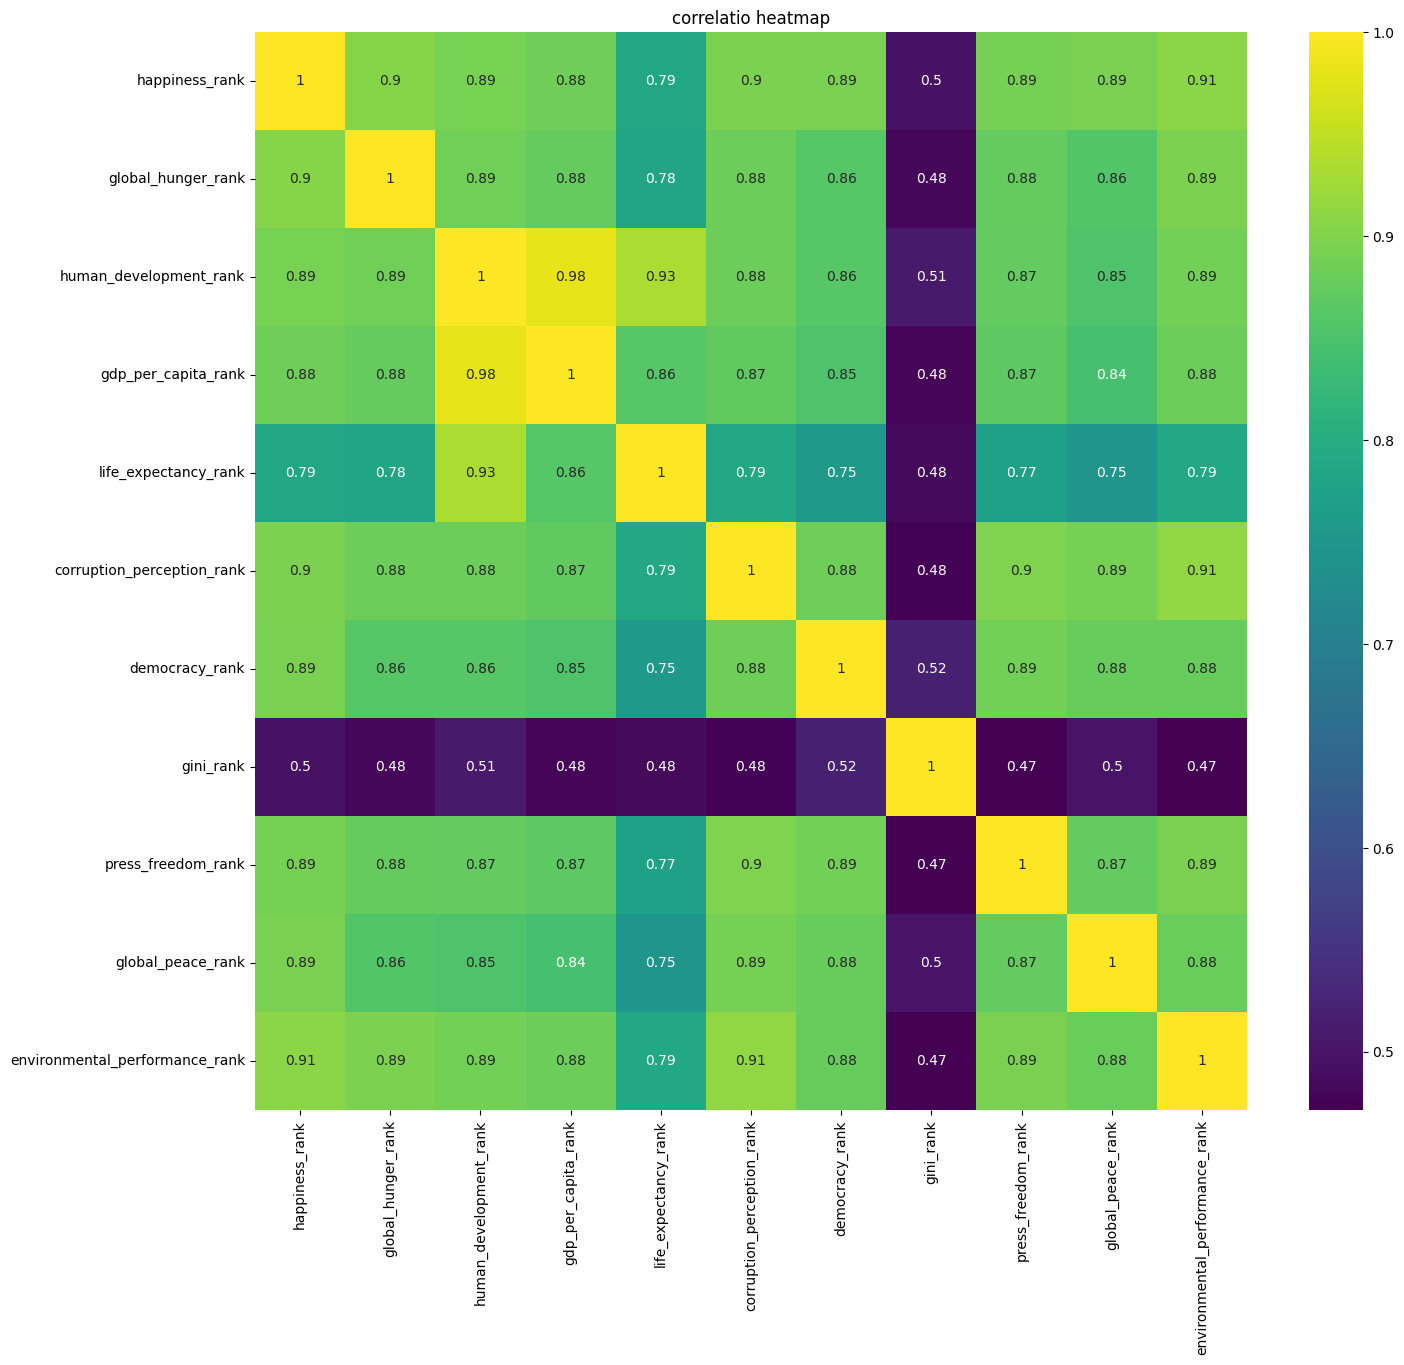

In [10]:
drop_col = df.drop(columns=['year'])
numeric_cols = drop_col.select_dtypes(include=['int64','float32','int32','float64'])
plt.figure(figsize=(16,14))
sns.heatmap(numeric_cols.corr() , annot=True ,cmap="viridis" )
plt.title("correlatio heatmap")
plt.show()

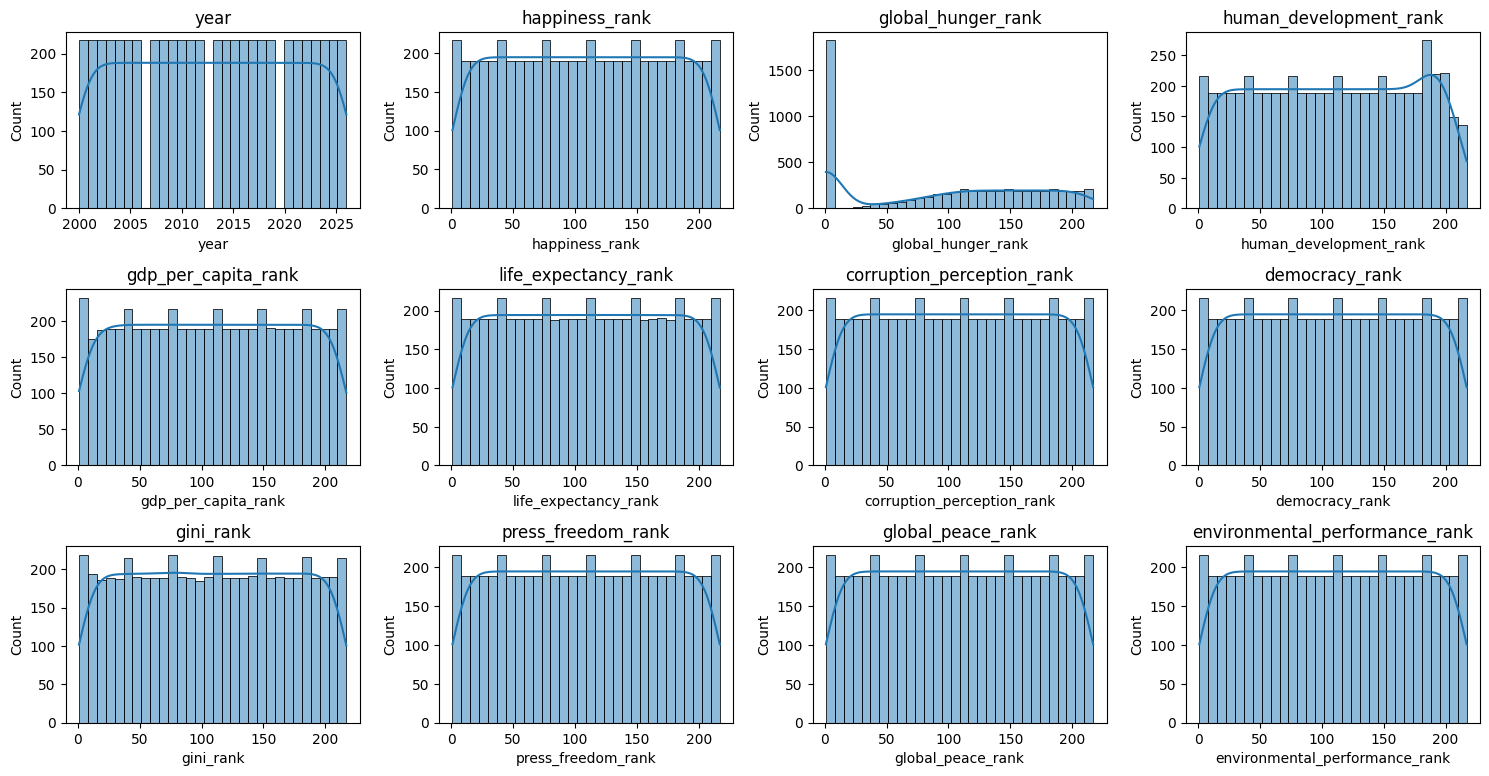

In [11]:
# distribution plot for numerical columns
numerical_cols = df.select_dtypes(include=["float64", "int64"]).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1) # adjust the number of rows and columns as needed
    sns.histplot(df[col], kde=True , bins = 30)
    plt.title(col)
plt.tight_layout()
plt.show()

In [12]:
df.columns

Index(['country', 'year', 'region', 'economic_tier', 'happiness_rank',
       'global_hunger_rank', 'human_development_rank', 'gdp_per_capita_rank',
       'life_expectancy_rank', 'corruption_perception_rank', 'democracy_rank',
       'gini_rank', 'press_freedom_rank', 'global_peace_rank',
       'environmental_performance_rank'],
      dtype='object')

1 . base on happiness rank show country distribution (year wise)

Index(['Norway', 'San Marino', 'Slovak Republic', 'Malta', 'Australia',
       'Panama', 'Sint Maarten (Dutch part)', 'Portugal', 'Bahamas, The',
       'Luxembourg'],
      dtype='object', name='country')

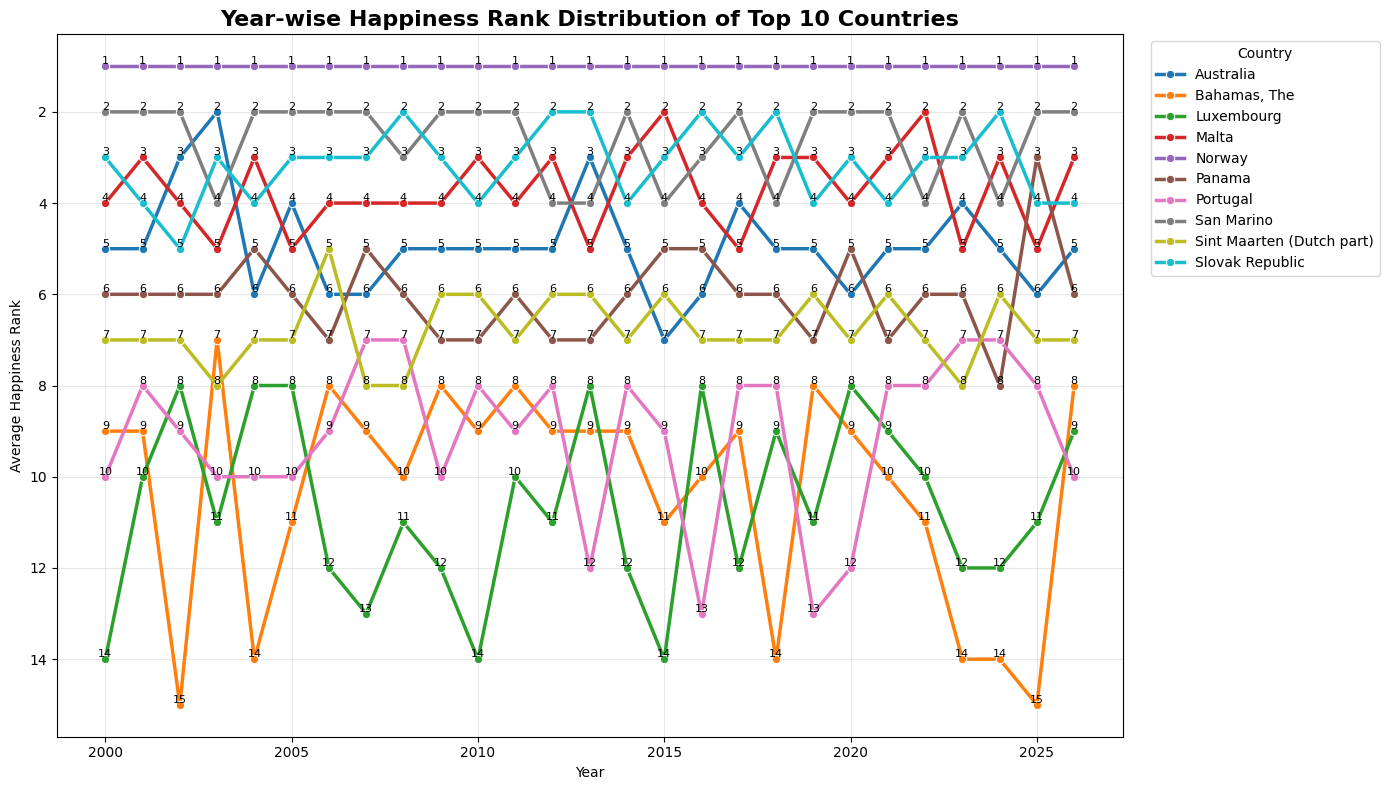

In [38]:
# Average happiness rank by year and country
country_rank = (
    df.groupby(['year', 'country'])['happiness_rank']
      .mean()
      .reset_index()
)

# Overall Top 10 happiest countries (higest average rank)
top10_country = (
    country_rank.groupby('country')['happiness_rank']
                .mean()
                .nsmallest(10)
                .index
)
display(top10_country)

# Filter data
plot_df = country_rank[country_rank['country'].isin(top10_country)]

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))

sns.lineplot(
    data=plot_df,
    x='year',
    y='happiness_rank',
    hue='country',
    marker='o',
    linewidth=2.5
)

# Data labels
for _, row in plot_df.iterrows():
    plt.text(
        row['year'],
        row['happiness_rank'],
        f"{row['happiness_rank']:.0f}",
        fontsize=8,
        ha='center',
        va='bottom'
    )

plt.gca().invert_yaxis()  # Rank 1 at the top
plt.title('Year-wise Happiness Rank Distribution of Top 10 Countries',
          fontsize=16, weight='bold')
plt.xlabel('Year')
plt.ylabel('Average Happiness Rank')
plt.grid(alpha=0.3)
plt.legend(title='Country', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

2 . overall happiness rank distribution base on country

,country,avg_rank
0,Norway,1.00
1,San Marino,2.59
2,Slovak Republic,3.15
3,Malta,3.70
4,Australia,4.93
5,Panama,6.04
6,Sint Maarten (Dutch part),6.78
7,Portugal,9.11
8,"Bahamas, The",10.26
9,Luxembourg,10.63


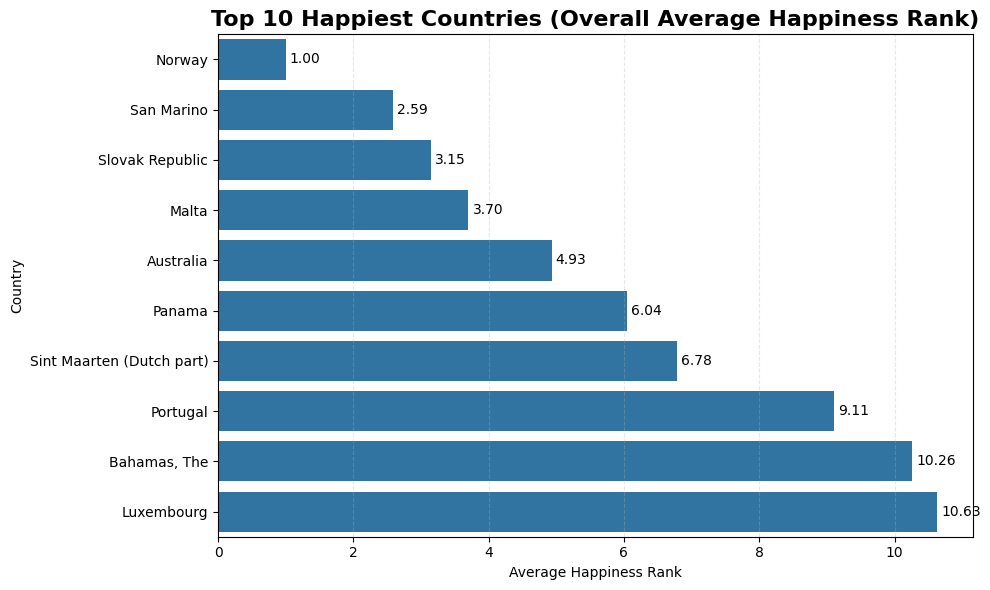

In [35]:
overall_happy = (
    df.groupby('country')
      .agg(avg_rank=('happiness_rank', 'mean'))
      .round(2)
      .sort_values(by='avg_rank', ascending=True)   # Lower rank = happier
      .head(10)
      .reset_index()
)

display(overall_happy)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=overall_happy,
    x='avg_rank',
    y='country'
)

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10)

plt.title("Top 10 Happiest Countries (Overall Average Happiness Rank)",
          fontsize=16, weight='bold')
plt.xlabel("Average Happiness Rank")
plt.ylabel("Country")
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

3 . top 10 coutry base on globle hunger rank each and every year

top 10 country base on avg hunge rank for each year


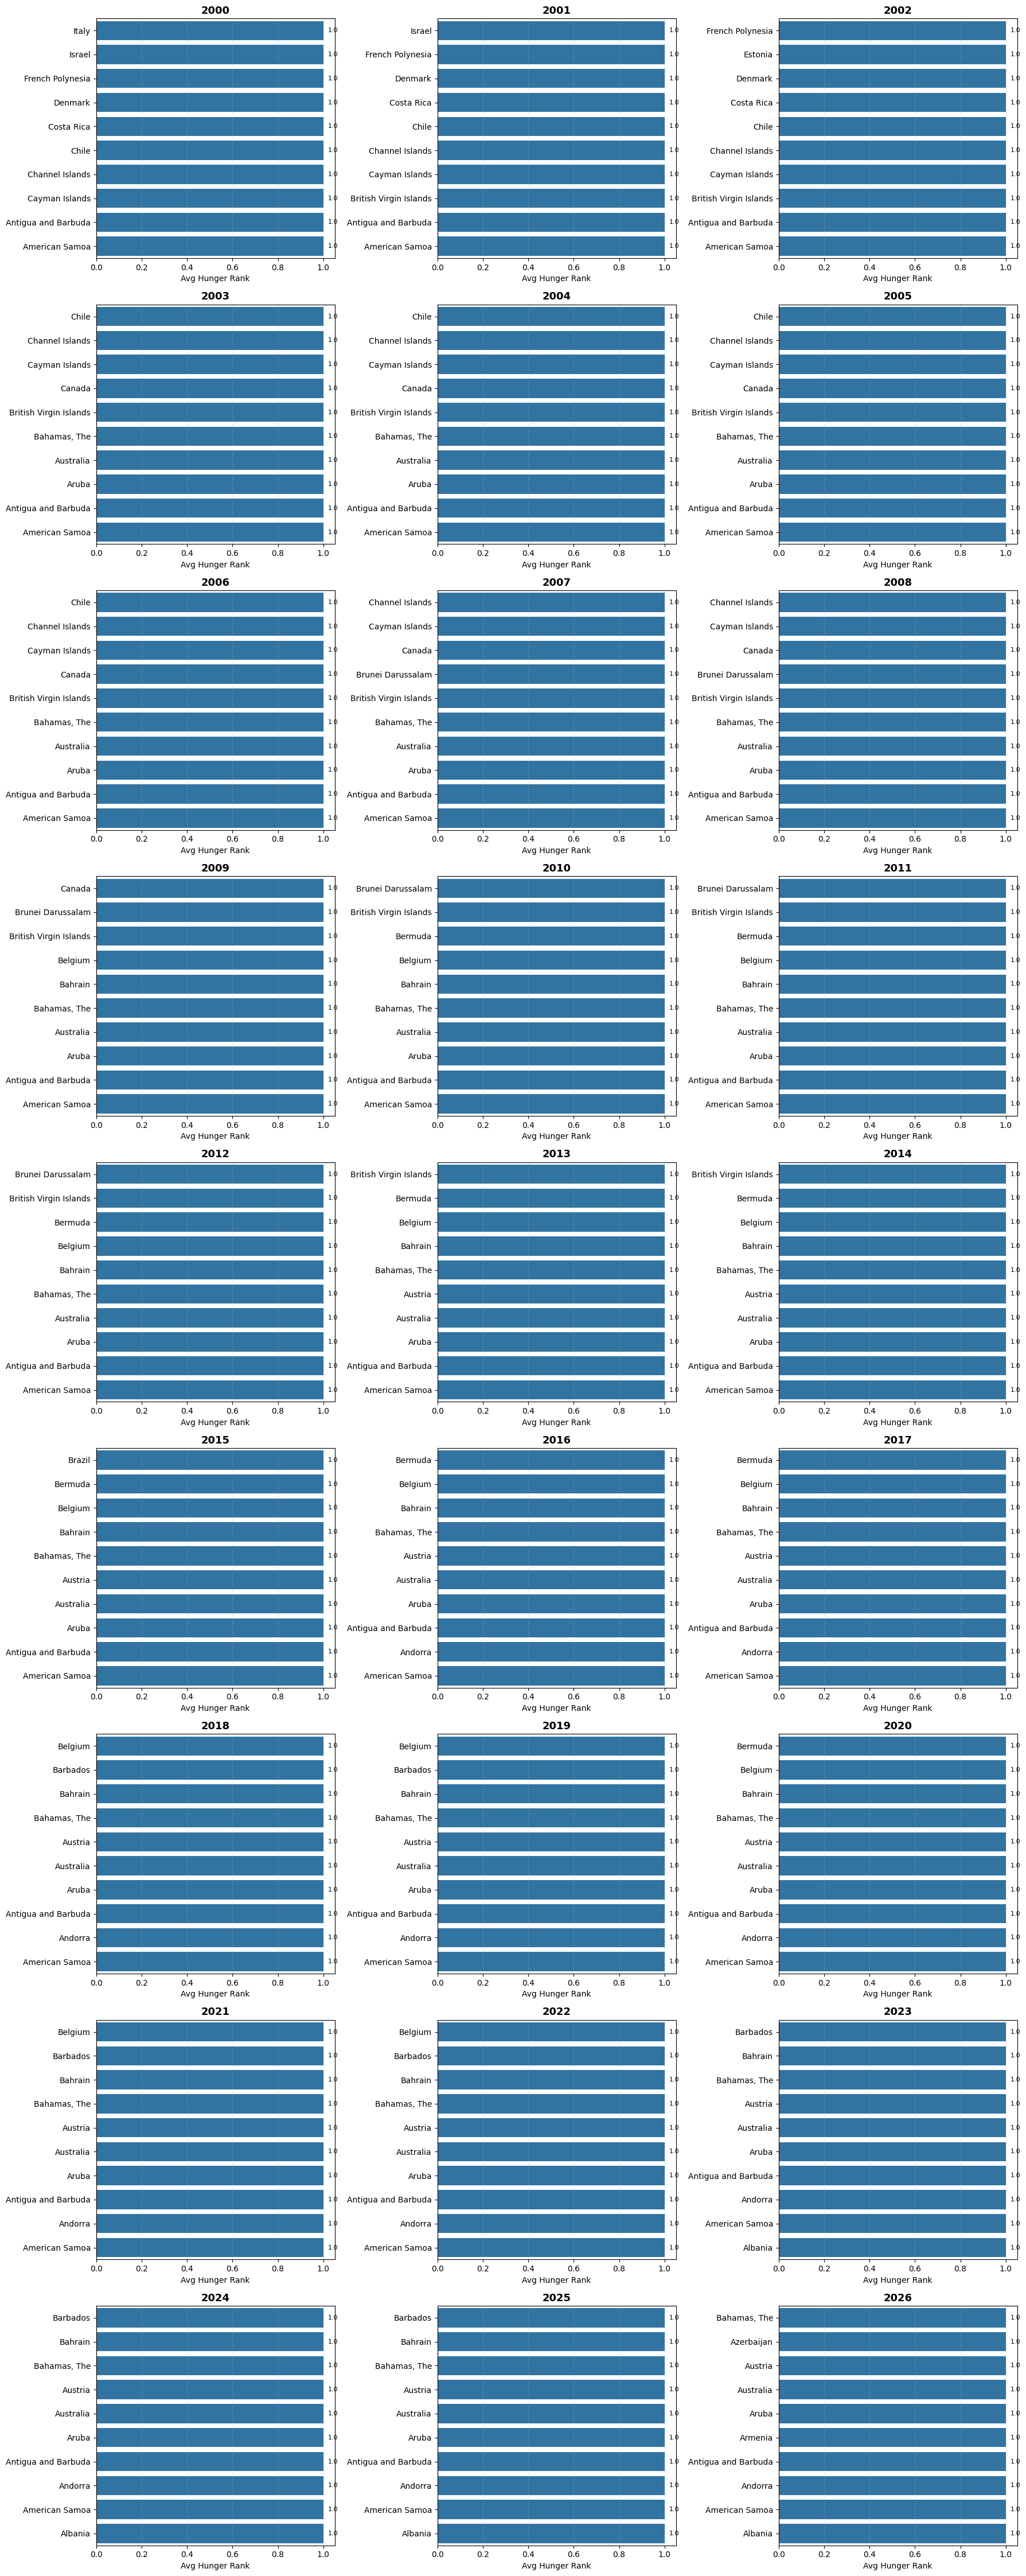

In [50]:
# Average Global Hunger Rank by Year and Country
mean_rank = (
    df.groupby(['year', 'country'])
      .agg(avg_hunger_rank=('global_hunger_rank', 'mean'))
      .round(2)
      .reset_index()
)

# Top 10 countries (lowest Global Hunger Rank) for each year
top10_per_year = (
    mean_rank
      .sort_values(['year', 'avg_hunger_rank'])
      .groupby('year', group_keys=False)
      .head(10)
      .reset_index(drop=True)
)

# display(top10_per_year)
print("top 10 country base on avg hunge rank for each year")

years = sorted(top10_per_year['year'].unique())

n_cols = 3
n_rows = math.ceil(len(years) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5 * n_rows)
)

# Convert axes to a flat array
axes = axes.flatten()

for i, year in enumerate(years):

    temp = (
        top10_per_year[top10_per_year['year'] == year]
        .sort_values('avg_hunger_rank', ascending=True)
    )

    ax = axes[i]

    sns.barplot(
        data=temp,
        x='avg_hunger_rank',
        y='country',
        ax=ax
    )

    # Data labels
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt='%.1f',
            padding=6,
            fontsize=8
        )

    ax.set_title(f"{year}", fontsize=13, weight='bold')
    ax.set_xlabel("Avg Hunger Rank")
    ax.set_ylabel("")
    ax.grid(axis='x', linestyle='--', alpha=0.3)
    ax.invert_yaxis()   # Rank 1 at the top

# Hide any unused subplots
for j in range(len(years), len(axes)):
    fig.delaxes(axes[j])

# fig.suptitle(
#     "Top 10 Countries by Global Hunger Rank (Year-wise)",
#     fontsize=18,
#     weight='bold'
# )

plt.tight_layout()
plt.show()

4 . top 10 country base on human development rank

In [ ]:
human_development = (
    df.groupby('country')
      .agg(avg_rank=('man', 'mean'))
      .round(2)
      .sort_values(by='avg_rank', ascending=True)   # Lower rank = happier
      .head(10)
      .reset_index()
)
